# Previsão de séries temporais com SARIMAX: ação da Microsoft

Alvo (endógena): `Open`, o preço de abertura da ação MSFT.
Base: `Microsoft_Stock.csv`, 1.510 pregões entre 01/04/2015 e 31/03/2021.
Split: 80% treino e 20% teste, com corte cronológico e sem embaralhamento.

### Pipeline

| # | Etapa |
|---|-------|
| 1 | Carga e preparação da base |
| 2 | Estacionariedade (ADF e KPSS) e ACF/PACF para definir `d` |
| 3 | Exógenas: classificação por tipo, correlação, VIF e seleção das 4 finais |
| 4 | Separação treino/teste (80/20) e escalonamento com `StandardScaler` |
| 5 | Ajuste do SARIMAX (grid search de ordem avaliado por BIC, já com `exog`) |
| 6 | Benchmarks: Naive e SARIMA sem exógenas, comparados por BIC e MAE |
| 7 | Previsão na escala original em USD e cenário what-if |
| 8 | Análise de resíduos (diagnóstico, Ljung-Box e Jarque-Bera) |
| 9 | Conclusões |

### A restrição que organiza todo o trabalho

Uma exógena só é utilizável se for conhecida no horizonte de previsão. Se não sabemos o valor
de `X` amanhã, não há como prever `y` amanhã. Por isso `High`, `Low`, `Close` e `Volume` do
próprio dia ficam de fora: eles só existem depois que o pregão termina. Usamos apenas as
versões defasadas em um dia, que já estão disponíveis no momento da abertura.

### Mapa das decisões

Cada linha abaixo é uma escolha que precisou ser feita, com a justificativa resumida e a seção
onde ela está desenvolvida.

| # | Decisão | Escolha | Justificativa | Seção |
|---|---|---|---|---|
| 1 | Índice da série | Inteiro sequencial (`t = 0,1,2...`) | A bolsa não abre todo dia. Forçar frequência diária criaria datas falsas que precisariam ser imputadas | 1 |
| 2 | Ordem de diferenciação `d` | `d = 1` | ADF e KPSS, que têm hipóteses opostas, concordam que uma diferença basta | 2 |
| 3 | Quais variáveis podem ser exógenas | Apenas dados de ontem (`lag-1`) e calendário | `High`, `Low` e `Close` de hoje só existem depois do pregão. Usá-los seria prever o presente com informação do futuro | 3 |
| 4 | Quantas exógenas | 4 | Todas significativas a 5% e com VIF próximo de 1, ou seja, sem redundância entre elas | 3 |
| 5 | Quais 4 | `close_lag1`, `ret_lag1`, `logvol_lag1`, `dow_sexta` | Cada uma carrega um tipo diferente de informação: nível, direção, intensidade e calendário | 3 |
| 6 | Tipo de corte treino/teste | Cronológico, sem embaralhar | Embaralhar série temporal treina o modelo com o futuro para prever o passado | 4 |
| 7 | Escalonamento | `StandardScaler` com `fit` só no treino | Se o scaler visse o teste, a média do futuro vazaria para o treino | 4 |
| 8 | Ordem `(p,d,q)(P,D,Q,m)` | Grid search de 32 combinações, escolha por BIC | Os limites da grade vêm da leitura da ACF/PACF e da semana de pregão | 5 |
| 9 | Critério de seleção | BIC em vez de AIC | O BIC pune parâmetro extra com mais força. Com exógenas no modelo, queremos evitar inflar a parte ARIMA | 5 |
| 10 | Benchmarks | Naive e SARIMA sem exógenas | O primeiro responde se o modelo serve; o segundo, se as exógenas valem a pena | 6 |
| 11 | Métricas | BIC, MAE, RMSE e MAPE | BIC e MAE são as principais; RMSE e MAPE complementam a leitura | 4, 6 |
| 12 | Escala do resultado final | USD | Erro em unidades padronizadas não comunica nada a quem lê | 7 |

### Glossário

| Termo | O que é | Como ler |
|---|---|---|
| Endógena (`endog`) | A série que queremos prever, o `y` | Aqui, `Open` |
| Exógena (`exog`) | Variáveis externas que ajudam a explicar `y` | Aqui, as 4 selecionadas |
| ADF | Teste de raiz unitária. H0: a série não é estacionária | `p < 0,05` indica série estacionária |
| KPSS | Teste com hipótese invertida. H0: a série é estacionária | `p < 0,05` indica série não estacionária |
| ACF / PACF | Gráficos de autocorrelação | Picos indicam quantos lags usar em `q` e `p` |
| VIF | Mede se uma variável repete informação de outra | Perto de 1 é ótimo, acima de 5 é problema |
| AIC / BIC | Critérios que equilibram ajuste e complexidade | Menor é melhor, e podem ser negativos |
| MAE | Erro médio absoluto, em USD | Quanto o modelo erra em média |
| RMSE | Erro quadrático médio, em USD | Pune erro grande mais que o MAE |
| MAPE | Erro percentual médio | Erro de X% sobre o preço |
| p-valor | Probabilidade de o resultado ser acaso | Abaixo de 0,05 é significativo |
| Ljung-Box | Testa se sobrou padrão nos resíduos. H0: é ruído branco | `p > 0,05` é o resultado desejado |
| Jarque-Bera | Testa normalidade dos resíduos. H0: são normais | `p < 0,05` indica que não são normais |

## 0. Dependências

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

SEED = 42
np.random.seed(SEED)


## 1. Carga e preparação da base

Esta seção lê o CSV, converte a coluna de data, ordena cronologicamente e confere a integridade
da base.

A checagem de nulos e duplicatas vem antes de tudo por um motivo prático: um único valor
faltante no meio da série quebra a diferenciação e os testes de estacionariedade, e uma data
duplicada faria o modelo contabilizar o mesmo pregão duas vezes. Descobrir isso agora custa
menos do que descobrir depois de treinar.

In [2]:
CAMINHO = "Microsoft_Stock.csv"   

df = pd.read_csv(CAMINHO)
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y %H:%M:%S")
df["Date"] = df["Date"].dt.normalize()          # remove o horário (16:00:00)
df = df.sort_values("Date").reset_index(drop=True)

print("Shape:", df.shape)
print("Período:", df["Date"].min().date(), "->", df["Date"].max().date())
print("Nulos por coluna:"); print(df.isna().sum())
print("Datas duplicadas:", df["Date"].duplicated().sum())
df.head()

Shape: (1511, 6)
Período: 2015-04-01 -> 2021-03-31
Nulos por coluna:
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64
Datas duplicadas: 0


,Date,Open,High,Low,Close,Volume
0,2015-04-01,40.6000,40.7600,40.3100,40.7200,36865322
1,2015-04-02,40.6600,40.7400,40.1200,40.2900,37487476
2,2015-04-06,40.3400,41.7800,40.1800,41.5500,39223692
3,2015-04-07,41.6100,41.9100,41.3100,41.5300,28809375
4,2015-04-08,41.4800,41.6900,41.0400,41.4200,24753438


Sobre o índice: a série é de dias úteis com buracos, por conta dos feriados da bolsa. Forçar uma
frequência (`B`) criaria datas sem pregão e exigiria imputação artificial. Por isso modelamos
sobre um índice inteiro sequencial (`t = 0, 1, 2, ...`) e guardamos as datas à parte, usadas
apenas nos gráficos. Isso elimina os avisos de frequência do `statsmodels` sem distorcer os dados.

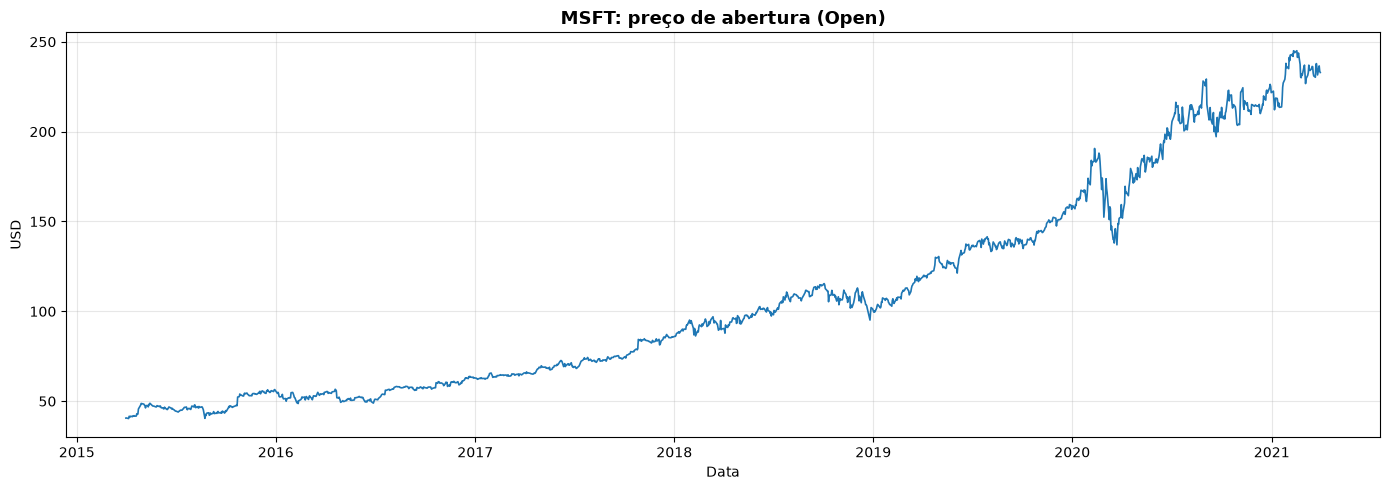

In [3]:
datas = df["Date"].copy()
serie = df["Open"].copy()
serie.index = pd.RangeIndex(len(serie))  

fig, ax = plt.subplots()
ax.plot(datas, serie.values, lw=1.2, color="#1f77b4")
ax.set_title("MSFT: preço de abertura (Open)", fontsize=13, weight="bold")
ax.set_xlabel("Data"); ax.set_ylabel("USD")
plt.tight_layout(); plt.show()

## 2. Estacionariedade e ordem de diferenciação (`d`)

O SARIMAX trabalha sobre série estacionária, aquela cuja média e variância não mudam ao longo do
tempo. O preço da MSFT saiu de cerca de US$ 40 para cerca de US$ 235 em seis anos, então a média
claramente muda. A letra `d` do modelo diz quantas vezes precisamos diferenciar a série, isto é,
trocar o preço pela variação do preço, até ela ficar estável.

Usamos dois testes porque ADF e KPSS têm hipóteses nulas opostas, e a concordância entre eles dá
uma conclusão mais segura do que qualquer um isolado.

| Teste | H0 | `p < 0,05` significa |
|---|---|---|
| ADF | a série não é estacionária | rejeita H0, logo a série é estacionária |
| KPSS | a série é estacionária | rejeita H0, logo a série não é estacionária |

In [4]:
def teste_estacionariedade(x, nome):
    x = pd.Series(x).dropna()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        adf = adfuller(x, autolag="AIC")
        kps = kpss(x, regression="c", nlags="auto")
    print(f"--- {nome} ---")
    print(f"ADF   : estat={adf[0]:.4f} | p-valor={adf[1]:.4f} -> {'ESTACIONÁRIA' if adf[1] < 0.05 else 'NÃO estacionária'} (H0 = raiz unitária)")
    print(f"KPSS  : estat={kps[0]:.4f} | p-valor={kps[1]:.4f} -> {'NÃO estacionária' if kps[1] < 0.05 else 'ESTACIONÁRIA'} (H0 = estacionária)")
    print()

teste_estacionariedade(serie, "Open (nível)")
teste_estacionariedade(serie.diff(), "Open (1ª diferença)")

--- Open (nível) ---
ADF   : estat=0.8239 | p-valor=0.9920 -> NÃO estacionária (H0 = raiz unitária)
KPSS  : estat=5.4112 | p-valor=0.0100 -> NÃO estacionária (H0 = estacionária)

--- Open (1ª diferença) ---
ADF   : estat=-9.9136 | p-valor=0.0000 -> ESTACIONÁRIA (H0 = raiz unitária)
KPSS  : estat=0.2374 | p-valor=0.1000 -> ESTACIONÁRIA (H0 = estacionária)



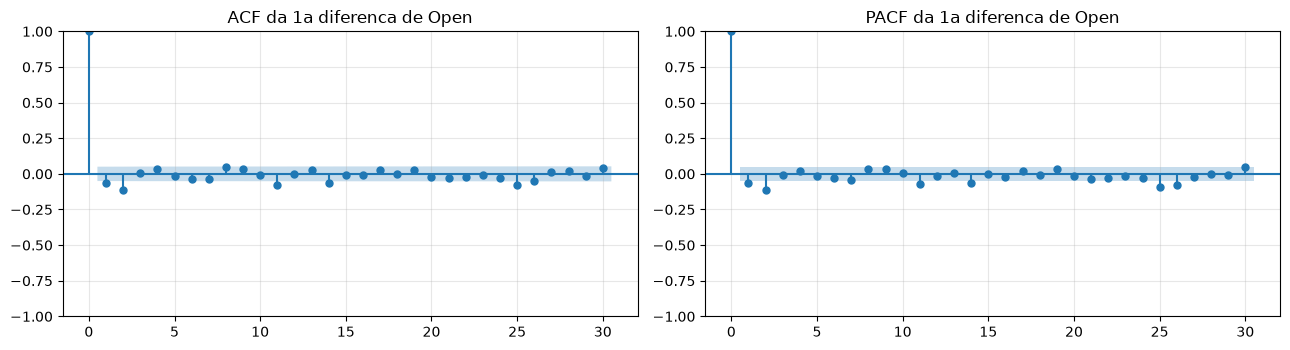

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
plot_acf(serie.diff().dropna(), lags=30, ax=axes[0], title="ACF da 1a diferenca de Open")
plot_pacf(serie.diff().dropna(), lags=30, ax=axes[1], title="PACF da 1a diferenca de Open", method="ywm")
plt.tight_layout(); plt.show()


### Leitura

Em nível a série é não estacionária: o ADF não rejeita a raiz unitária e o KPSS rejeita a
estacionariedade. Com uma diferença ela fica estacionária, o que fixa `d = 1`.

A ACF e a PACF da série diferenciada quase não mostram picos. Esse é o comportamento de um
passeio aleatório, padrão esperado em preço de ativo.

## 3. Variáveis exógenas: tipo, correlação, VIF e seleção

A regra que manda aqui já foi enunciada na abertura: a exógena precisa ser conhecida no horizonte
de previsão. Toda candidata tem que se encaixar em um destes três tipos.

| Tipo | Exemplo | Disponível no futuro? | Como obter |
|---|---|---|---|
| Determinística | Feriado, dia da semana, dummy mensal | Sempre | `pd.get_dummies` ou calendário |
| Prevista | Temperatura, câmbio, PIB | Precisa ser prevista | Modelo auxiliar, cujo erro propaga para `y` |
| Cenário what-if | Promoção ou ausência de promoção | Hipotética | `get_forecast(exog=cenario)` para sensibilidade |

`High`, `Low`, `Close` e `Volume` do mesmo dia não se encaixam em nenhum dos três, porque só
existem depois do pregão. Trabalhamos então com as versões defasadas em um dia. Como a próxima
célula detalha, elas são do tipo Prevista, e não Determinística.

### Por que as `lag-1` são Prevista e não Determinística

Esta distinção define o resto do notebook.

Para prever o próximo pregão (`h = 1`), `close_lag1` já é um número conhecido, porque o mercado
fechou ontem. Nesse horizonte ela se comporta como determinística.

Para prever o pregão seguinte (`h = 2`), `close_lag1` passa a ser o fechamento de amanhã, que
ainda não aconteceu. Ela vira Prevista: exigiria um modelo auxiliar, e o erro desse modelo
propagaria para `Open`.

Isso tem uma consequência prática que vale deixar explícita. Na avaliação deste notebook o
`statsmodels` recebe `X_te` com os valores reais do período de teste. É o procedimento padrão,
mas representa um teto otimista: fora da amostra essas exógenas precisariam vir de um modelo
auxiliar. Por construção, o modelo é mais confiável quanto menor o horizonte.

A `dow_sexta` não tem esse problema, já que calendário é conhecido para sempre. É a vantagem
estrutural do tipo Determinística.

O terceiro tipo, cenário what-if, não serve para medir erro. Ele serve para análise de
sensibilidade, e está demonstrado na seção 7.

In [6]:
ex = df.copy()

# --- Exógenas candidatas (todas defasadas em 1 pregão) ---
ex["close_lag1"]  = ex["Close"].shift(1)                                   # fechamento de ontem
ex["high_lag1"]   = ex["High"].shift(1)
ex["low_lag1"]    = ex["Low"].shift(1)
ex["range_lag1"]  = (ex["High"] - ex["Low"]).shift(1)                      # volatilidade intradiária de ontem
ex["ret_lag1"]    = ex["Close"].pct_change().shift(1) * 100                # retorno % de ontem
ex["logvol_lag1"] = np.log(ex["Volume"]).shift(1)                          # volume (log) de ontem
ex["gap_lag1"]    = (ex["Open"] - ex["Close"].shift(1)).shift(1)           # gap de abertura de ontem
ex["vol5_lag1"]   = ex["Close"].pct_change().rolling(5).std().shift(1)*100 # volatilidade 5d

# --- Dummy de calendario (deterministica: conhecida no futuro) ---
ex["dow_sexta"] = (ex["Date"].dt.dayofweek == 4).astype(float)

# Remove as linhas iniciais com NaN gerados pelos lags/rolling
ex = ex.dropna().reset_index(drop=True)
datas = ex["Date"].copy()
y = ex["Open"].copy()
y.index = pd.RangeIndex(len(y))

print("Shape após lags:", ex.shape)
ex[["Date", "Open", "close_lag1", "range_lag1", "ret_lag1", "logvol_lag1", "vol5_lag1"]].head()

Shape após lags: (1505, 15)


,Date,Open,close_lag1,range_lag1,ret_lag1,logvol_lag1,vol5_lag1
0,2015-04-10,41.6300,41.4800,0.3700,0.1449,17.0629,1.6019
1,2015-04-13,41.4000,41.7200,0.5400,0.5786,17.1485,1.3879
2,2015-04-14,41.8000,41.7600,0.6700,0.0959,17.2259,0.3107
3,2015-04-15,41.7600,41.6500,0.6400,-0.2634,17.0037,0.3491
4,2015-04-16,41.9500,42.2600,0.7800,1.4646,17.1240,0.6639


### Passo 1: correlação com o alvo

Faixas de referência: abaixo de 0,20 é fraca; de 0,20 a 0,40 é leve ou moderada; de 0,40 a 0,70
é moderada ou forte; acima de 0,70 é forte.

Vale uma ressalva antes de olhar os números. Correlação alta não garante utilidade e correlação
baixa não garante inutilidade, porque a correlação olha cada variável isolada enquanto o modelo
olha todas em conjunto.

In [7]:
# ----- Correlação das candidatas com o alvo -----
CANDIDATAS = ["close_lag1", "high_lag1", "low_lag1", "range_lag1",
              "ret_lag1", "logvol_lag1", "gap_lag1", "vol5_lag1"]

corr = ex[CANDIDATAS + ["Open"]].corr()["Open"].drop("Open").sort_values(key=abs, ascending=False)

def classifica(c):
    a = abs(c)
    if a < 0.20:  return "fraca"
    if a < 0.40:  return "leve/moderada"
    if a < 0.70:  return "moderada/forte"
    return "forte"

display(pd.DataFrame({"corr_com_Open": corr, "classificacao": corr.map(classifica)}))


,corr_com_Open,classificacao
close_lag1,0.9997,forte
low_lag1,0.9995,forte
high_lag1,0.9995,forte
range_lag1,0.6657,moderada/forte
vol5_lag1,0.1832,fraca
logvol_lag1,0.0670,fraca
gap_lag1,0.0537,fraca
ret_lag1,0.0216,fraca


### Passo 2: VIF e multicolinearidade

Quando duas variáveis dizem quase a mesma coisa, o modelo não consegue decidir a qual atribuir o
efeito. O resultado são coeficientes instáveis e p-valores pouco confiáveis. O VIF responde se
cada variável traz informação própria.

| VIF | Diagnóstico |
|---|---|
| perto de 1 | sem colinearidade |
| 1 a 5 | aceitável |
| acima de 5 | problema |

In [8]:
def calcula_vif(X):
    Xc = add_constant(X.astype(float), has_constant="add")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        vifs = [variance_inflation_factor(Xc.values, i) for i in range(Xc.shape[1])]
    out = pd.DataFrame({"variavel": Xc.columns, "VIF": vifs})
    out = out[out["variavel"] != "const"].sort_values("VIF", ascending=False).reset_index(drop=True)
    out["diagnostico"] = pd.cut(out["VIF"], [0, 1.0001, 3, 5, 10, np.inf],
                                labels=["sem colinearidade", "tranquilo", "atenção",
                                        "possível problema", "problema forte"])
    return out

print("VIF do conjunto completo de candidatas:")
display(calcula_vif(ex[CANDIDATAS]))

VIF do conjunto completo de candidatas:


,variavel,VIF,diagnostico
0,high_lag1,"1,000,799,917,193,443.5000",problema forte
1,low_lag1,"1,000,799,917,193,443.5000",problema forte
2,range_lag1,"1,000,799,917,193,443.5000",problema forte
3,close_lag1,"7,641.8312",problema forte
4,ret_lag1,3.7913,atenção
5,vol5_lag1,2.0281,tranquilo
6,gap_lag1,1.9758,tranquilo
7,logvol_lag1,1.7237,tranquilo


O diagnóstico é direto: `close_lag1`, `high_lag1` e `low_lag1` carregam praticamente a mesma
informação, já que todas orbitam o preço de ontem, e por isso o VIF explode. Descartamos
`high_lag1` e `low_lag1`.

### Seleção final

Ficamos com quatro variáveis, cada uma trazendo um tipo diferente de informação e sem
redundância entre si.

| # | Variável | Tipo | Informação que carrega |
|---|---|---|---|
| 1 | `close_lag1`  | Prevista       | Nível do preço, o fechamento de ontem |
| 2 | `ret_lag1`    | Prevista       | Direção do movimento, o retorno percentual de ontem |
| 3 | `logvol_lag1` | Prevista       | Intensidade de negociação, o volume de ontem |
| 4 | `dow_sexta`   | Determinística | Calendário, o efeito de sexta-feira |

A escolha não é arbitrária: são exatamente as quatro que foram significativas a 5% quando o
modelo foi estimado com o conjunto completo de candidatas. `range_lag1` (p = 0,21) e `vol5_lag1`
(p = 0,30) não passaram, e saíram. As dummies de terça, quarta e quinta também não foram
significativas, e apenas a de sexta permaneceu.

Manter os dois tipos, Prevista e Determinística, é proposital. Permite comparar como cada um se
comporta no horizonte de previsão.

In [9]:
EXOG_COLS = ["close_lag1", "ret_lag1", "logvol_lag1", "dow_sexta"]

print("VIF do conjunto final (4 exógenas):")
display(calcula_vif(ex[EXOG_COLS]))

VIF do conjunto final (4 exógenas):


,variavel,VIF,diagnostico
0,logvol_lag1,1.0060,tranquilo
1,close_lag1,1.0053,tranquilo
2,ret_lag1,1.0025,tranquilo
3,dow_sexta,1.0004,tranquilo


In [10]:
X = ex[EXOG_COLS].astype(float).reset_index(drop=True)
X.index = pd.RangeIndex(len(X))

print("Exógenas utilizadas:", EXOG_COLS)
print("Shape X:", X.shape, "| Shape y:", y.shape)
X.head()

Exógenas utilizadas: ['close_lag1', 'ret_lag1', 'logvol_lag1', 'dow_sexta']
Shape X: (1505, 4) | Shape y: (1505,)


,close_lag1,ret_lag1,logvol_lag1,dow_sexta
0,41.4800,0.1449,17.0629,1.0000
1,41.7200,0.5786,17.1485,0.0000
2,41.7600,0.0959,17.2259,0.0000
3,41.6500,-0.2634,17.0037,0.0000
4,42.2600,1.4646,17.1240,0.0000


## 4. Separação treino/teste e escalonamento

Quatro decisões se concentram aqui.

A primeira é que o corte é cronológico, nunca aleatório. Os 80% mais antigos treinam e os 20%
mais recentes testam. Em problemas comuns de machine learning embaralha-se a base antes de
dividir, mas aqui isso seria um erro grave: o modelo treinaria com dados de 2021 para prever
2019, usando o futuro para explicar o passado. O resultado pareceria ótimo e não valeria nada.
O horizonte de previsão `h` é igual ao tamanho do teste.

A segunda é o escalonamento com `StandardScaler`. As variáveis estão em unidades muito
diferentes: preço em dezenas de dólares, retorno em percentual, volume em logaritmo e dummy em
0 ou 1. Sem padronizar, a otimização numérica do SARIMAX fica mal condicionada e converge com
mais dificuldade. O `StandardScaler` transforma cada variável para média 0 e desvio 1.

A terceira é a mais fácil de errar: o `fit` acontece só no treino. Se chamássemos `fit_transform`
na base inteira, a média e o desvio usados na padronização já conteriam informação do período de
teste. Por isso usamos `fit_transform` no treino e apenas `transform` no teste.

Há um sinal de que isso foi feito certo, visível na saída abaixo. O treino padronizado tem média
0 e desvio 1 exatos, mas o teste não, porque foi transformado com os parâmetros do treino. Se o
teste também desse 0 e 1 redondos, seria sintoma de vazamento.

A quarta é guardar o `scaler_y`. Ele será necessário no final para converter as previsões de
volta para dólares.

Total        : 1505 observações
Treino (80%) : 1204  [2015-04-10 -> 2020-01-21]
Teste  (20%) : 301  [2020-01-22 -> 2021-03-31]
Horizonte h  : 301 passos


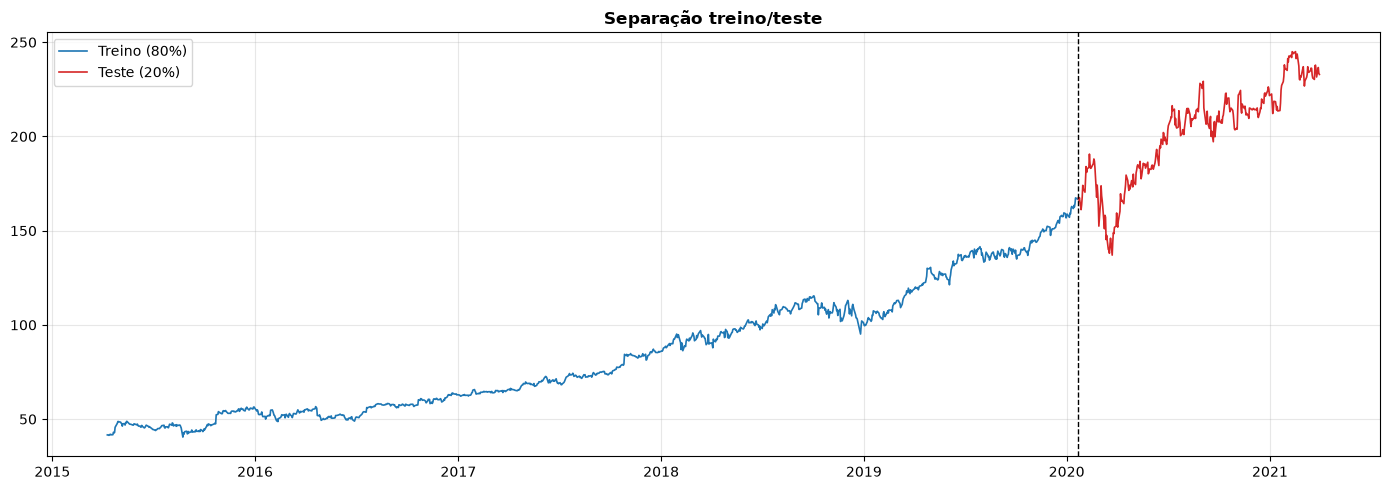

In [11]:
n = len(y)
corte = int(n * 0.80)
h = n - corte                       # horizonte de previsão = tamanho do teste

y_tr_raw, y_te_raw = y.iloc[:corte], y.iloc[corte:]
X_tr_raw, X_te_raw = X.iloc[:corte], X.iloc[corte:]
datas_tr, datas_te = datas.iloc[:corte], datas.iloc[corte:]

print(f"Total        : {n} observações")
print(f"Treino (80%) : {len(y_tr_raw)}  [{datas_tr.iloc[0].date()} -> {datas_tr.iloc[-1].date()}]")
print(f"Teste  (20%) : {len(y_te_raw)}  [{datas_te.iloc[0].date()} -> {datas_te.iloc[-1].date()}]")
print(f"Horizonte h  : {h} passos")

fig, ax = plt.subplots()
ax.plot(datas_tr, y_tr_raw, label="Treino (80%)", color="#1f77b4", lw=1.2)
ax.plot(datas_te, y_te_raw, label="Teste (20%)", color="#d62728", lw=1.2)
ax.axvline(datas_te.iloc[0], color="black", ls="--", lw=1)
ax.set_title("Separação treino/teste", weight="bold")
ax.legend(); plt.tight_layout(); plt.show()

Treino escalonado -> média: 0.000000 | desvio: 1.000000
Teste  escalonado -> média: 3.635147 | desvio: 0.781145  (esperado != 0/1: usa os parâmetros do treino)


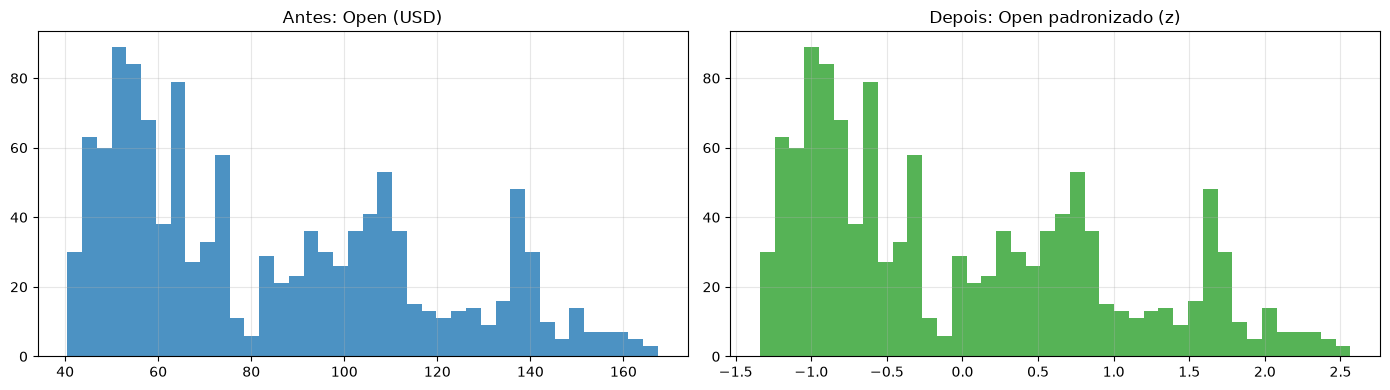

In [12]:
# ---------- Escalonamento (fit SOMENTE no treino) ----------
scaler_y = StandardScaler()
scaler_X = StandardScaler()

y_tr = pd.Series(scaler_y.fit_transform(y_tr_raw.values.reshape(-1, 1)).ravel(),
                 index=y_tr_raw.index, name="Open_scaled")
y_te = pd.Series(scaler_y.transform(y_te_raw.values.reshape(-1, 1)).ravel(),
                 index=y_te_raw.index, name="Open_scaled")

X_tr = pd.DataFrame(scaler_X.fit_transform(X_tr_raw), columns=X.columns, index=X_tr_raw.index)
X_te = pd.DataFrame(scaler_X.transform(X_te_raw),     columns=X.columns, index=X_te_raw.index)

print("Treino escalonado -> média: %.6f | desvio: %.6f" % (y_tr.mean(), y_tr.std(ddof=0)))
print("Teste  escalonado -> média: %.6f | desvio: %.6f  (esperado != 0/1: usa os parâmetros do treino)"
      % (y_te.mean(), y_te.std(ddof=0)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(y_tr_raw, bins=40, color="#1f77b4", alpha=0.8); axes[0].set_title("Antes: Open (USD)")
axes[1].hist(y_tr,     bins=40, color="#2ca02c", alpha=0.8); axes[1].set_title("Depois: Open padronizado (z)")
plt.tight_layout(); plt.show()

### Métricas

| Métrica | O que mede |
|---|---|
| MAE | erro médio em USD, a métrica principal do trabalho |
| RMSE | pune erro grande; se for muito maior que o MAE, há poucos erros muito grandes |
| MAPE | erro percentual, que independe da escala do papel |

In [13]:
# ---------- Funções auxiliares de avaliação ----------
def inverter_escala(valores_escalados):
    """Volta da escala padronizada para USD."""
    v = np.asarray(valores_escalados).reshape(-1, 1)
    return scaler_y.inverse_transform(v).ravel()

def metricas(y_real, y_pred, nome=""):
    y_real = np.asarray(y_real, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae  = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100
    return {"modelo": nome, "MAE": mae, "RMSE": rmse, "MAPE_%": mape}

resultados = []

## 5. SARIMAX

O modelo `SARIMAX(p, d, q)(P, D, Q, m)` combina quatro ideias, mais as exógenas.

| Parte | Nome | Papel no modelo |
|---|---|---|
| AR (`p`) | AutoRegressive | Quantos valores passados de `y` entram na equação |
| I (`d`) | Integrated | Quantas diferenciações estabilizam a série |
| MA (`q`) | Moving Average | Quantos erros passados entram na equação |
| S (`P,D,Q,m`) | Seasonal | O mesmo, aplicado ao ciclo sazonal de tamanho `m` |
| X (`exog`) | eXogenous | As variáveis externas, o que diferencia SARIMAX de SARIMA |

A importância do X aparece quando a variação em `y` é causada por um fator externo. O SARIMA
tenta capturar esse efeito nos lags, mas nunca inteiramente, porque fatores externos têm causa e
não apenas padrão. O SARIMAX permite informar a causa diretamente.

### Definição e otimização dos parâmetros

A ordem é escolhida por busca em grade estruturada (`Grid Search`), testando todas as
combinações de `(p, d, q)` vezes `(P, D, Q, m)` sobre o conjunto de treino e selecionando a
melhor pelo critério BIC, que aplica o princípio da parcimônia.

| Parâmetro | Valores testados | Justificativa |
|---|---|---|
| `p` | 0 e 1 | a PACF da série diferenciada não mostra estrutura além do primeiro lag |
| `d` | 1 | ADF e KPSS concordam que uma diferença basta |
| `q` | 0 e 1 | a ACF da série diferenciada decai logo após o primeiro lag |
| `P`, `D`, `Q` | 0 e 1 | testa a presença de componente sazonal sem inflar o modelo |
| `m` | 5 | a semana de pregão tem cinco dias, a bolsa não abre no fim de semana |

São 2 x 1 x 2 x 2 x 2 x 2 = 32 combinações. O BIC penaliza parâmetro com mais força que o AIC
(`k·ln(n)` contra `2k`), o que é apropriado quando já há exógenas no modelo e queremos evitar
inflar a parte ARIMA sem ganho real.

A busca roda já com `exog=X_tr`, de modo que a parte ARIMA capture exatamente o que sobra depois
da contribuição das exógenas. Combinações que não convergem são descartadas pelo `try/except`,
como é padrão em grid search de séries temporais.

In [14]:
# ---------- Grid Search estruturado: (p,d,q) x (P,D,Q,m) selecionado por BIC ----------
import itertools, warnings

p_range = [0, 1]
d_range = [1]
q_range = [0, 1]
P_range = [0, 1]
D_range = [0, 1]
Q_range = [0, 1]
m = 5

orders          = list(itertools.product(p_range, d_range, q_range))
seasonal_orders = list(itertools.product(P_range, D_range, Q_range))

results_sarima   = []
best_sarima_model = None
best_sarima_bic   = float("inf")

for order in orders:
    for s_order in seasonal_orders:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                m_fit = SARIMAX(
                    y_tr,
                    exog=X_tr,
                    order=order,
                    seasonal_order=(*s_order, m),
                    trend="n",
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                ).fit(disp=False)

            results_sarima.append({
                "Modelo": f"SARIMAX{order}{(*s_order, m)}",
                "order": order,
                "seasonal": (*s_order, m),
                "BIC": m_fit.bic,
                "AIC": m_fit.aic,
            })

            if m_fit.bic < best_sarima_bic:
                best_sarima_bic   = m_fit.bic
                best_sarima_model = m_fit
        except Exception:
            continue

df_sarima_grid = pd.DataFrame(results_sarima).sort_values("BIC").reset_index(drop=True)
print(f"{len(df_sarima_grid)} de {len(orders) * len(seasonal_orders)} combinações convergiram")
print("=== TOP 10 MODELOS SELECIONADOS PELO CRITÉRIO BIC ===")
display(df_sarima_grid[["Modelo", "BIC", "AIC"]].head(10))

32 de 32 combinações convergiram
=== TOP 10 MODELOS SELECIONADOS PELO CRITÉRIO BIC ===


,Modelo,BIC,AIC
0,"SARIMAX(0, 1, 1)(0, 0, 0, 5)","-5,646.4818","-5,677.0273"
1,"SARIMAX(1, 1, 1)(0, 0, 0, 5)","-5,639.3956","-5,675.0319"
2,"SARIMAX(0, 1, 1)(1, 0, 0, 5)","-5,621.6798","-5,657.2986"
3,"SARIMAX(0, 1, 1)(0, 0, 1, 5)","-5,611.4968","-5,647.1039"
4,"SARIMAX(1, 1, 1)(1, 0, 0, 5)","-5,606.6067","-5,647.3073"
5,"SARIMAX(0, 1, 1)(1, 0, 1, 5)","-5,604.6305","-5,645.3244"
6,"SARIMAX(1, 1, 1)(0, 0, 1, 5)","-5,597.0052","-5,637.6991"
7,"SARIMAX(1, 1, 1)(1, 0, 1, 5)","-5,582.1513","-5,627.9320"
8,"SARIMAX(0, 1, 1)(0, 1, 1, 5)","-5,563.6209","-5,599.1988"
9,"SARIMAX(0, 1, 1)(1, 1, 1, 5)","-5,552.4322","-5,593.0926"


In [15]:
ORDER    = df_sarima_grid.loc[0, "order"]
SEASONAL = df_sarima_grid.loc[0, "seasonal"]
print(f"Melhor modelo selecionado: {df_sarima_grid.loc[0, 'Modelo']}")
print(f"BIC = {df_sarima_grid.loc[0, 'BIC']:,.4f} | AIC = {df_sarima_grid.loc[0, 'AIC']:,.4f}")
print(best_sarima_model.summary())

Melhor modelo selecionado: SARIMAX(0, 1, 1)(0, 0, 0, 5)
BIC = -5,646.4818 | AIC = -5,677.0273
                               SARIMAX Results                                
Dep. Variable:            Open_scaled   No. Observations:                 1204
Model:               SARIMAX(0, 1, 1)   Log Likelihood                2844.514
Date:                Tue, 06 Oct 2026   AIC                          -5677.027
Time:                        06:29:17   BIC                          -5646.482
Sample:                             0   HQIC                         -5665.522
                               - 1204                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
close_lag1      1.0001      0.001   1867.002      0.000       0.999       1.001
ret_lag1       -0.0016      0.001 

In [16]:
# ---------- Ajuste do modelo final ----------
sarimax = SARIMAX(y_tr, exog=X_tr, order=ORDER, seasonal_order=SEASONAL,
                  trend="n", enforce_stationarity=False,
                  enforce_invertibility=False).fit(disp=False)
print(sarimax.summary())

                               SARIMAX Results                                
Dep. Variable:            Open_scaled   No. Observations:                 1204
Model:               SARIMAX(0, 1, 1)   Log Likelihood                2844.514
Date:                Tue, 06 Oct 2026   AIC                          -5677.027
Time:                        06:29:18   BIC                          -5646.482
Sample:                             0   HQIC                         -5665.522
                               - 1204                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
close_lag1      1.0001      0.001   1867.002      0.000       0.999       1.001
ret_lag1       -0.0016      0.001     -3.114      0.002      -0.003      -0.001
logvol_lag1     0.0015      0.001      2.025    

### As exógenas ajudaram? Leitura dos coeficientes

Agora conferimos, uma a uma, se as quatro variáveis escolhidas de fato contribuem. Para cada uma
o modelo devolve dois números.

O coeficiente indica o quanto `Open` se move quando aquela variável sobe um desvio-padrão. Como
as variáveis estão padronizadas, os coeficientes são diretamente comparáveis entre si.

O p-valor indica a probabilidade de esse efeito ser apenas acaso. Abaixo de 0,05 consideramos a
variável significativa.

In [17]:
# ---------- Significância das exógenas ----------
coefs = pd.DataFrame({
    "coeficiente": sarimax.params,
    "p_valor": sarimax.pvalues,
})
coefs["significativa_5%"] = np.where(coefs["p_valor"] < 0.05, "SIM", "não")
display(coefs.loc[[c for c in coefs.index if c in EXOG_COLS]])

,coeficiente,p_valor,significativa_5%
close_lag1,1.0001,0.0000,SIM
ret_lag1,-0.0016,0.0018,SIM
logvol_lag1,0.0015,0.0429,SIM
dow_sexta,0.0013,0.0330,SIM


In [18]:
# ---------- Previsão no horizonte completo (301 passos) ----------
fc = sarimax.get_forecast(steps=h, exog=X_te)
pred_horizonte = inverter_escala(fc.predicted_mean)
ic = fc.conf_int(alpha=0.05)
ic_lo = inverter_escala(ic.iloc[:, 0]); ic_hi = inverter_escala(ic.iloc[:, 1])

resultados.append(metricas(y_te_raw, pred_horizonte, "SARIMAX"))
pd.DataFrame(resultados)

,modelo,MAE,RMSE,MAPE_%
0,SARIMAX,1.8980,2.8370,1.0101


## 6. Benchmarks

Um MAE de US$ 1,90 não significa nada sozinho. Ele só vira informação quando comparado a algo.
Usamos dois benchmarks, cada um respondendo a uma pergunta distinta.

O primeiro é o Naive, ou passeio aleatório, e responde se o modelo serve para alguma coisa. A
previsão é simplesmente o último valor observado. É o benchmark canônico de série financeira
porque a hipótese de mercado eficiente afirma que o preço de um ativo segue um passeio
aleatório. Se isso for verdade, o melhor palpite para amanhã é o preço de hoje e nenhum modelo
consegue vencer. Um SARIMAX que não bata o Naive não tem utilidade, por melhor que seja o BIC.

O segundo é o SARIMA sem exógenas, e responde se as exógenas valem a pena. Mesma ordem, mesma
série, mesmo corte e mesmo escalonamento, com a única diferença de `exog=None`. É um estudo de
ablação: isola a contribuição das exógenas de todo o resto. Sem ele não dá para saber se o
desempenho veio das variáveis construídas ou simplesmente da estrutura ARIMA.

Outras opções foram consideradas e descartadas. Média histórica e média móvel são piores que o
Naive em série com tendência, o que inflaria artificialmente o ganho do modelo. Drift, que é o
Naive somado a uma tendência linear, foi descartado porque o período de teste contém o crash da
COVID, onde qualquer tendência extrapolada erra muito. O Naive é o mais duro dos três e também o
mais honesto.

Os dois benchmarks são avaliados exatamente como o SARIMAX: mesmo horizonte, mesmo conjunto de
teste e mesmas métricas.

In [19]:
# ---------- Benchmark 1: Naive / passeio aleatorio (base model) ----------
# Sem novas observacoes, a previsao congela no ultimo valor conhecido do treino
naive_horizonte = np.repeat(y_tr_raw.iloc[-1], h)

resultados.append(metricas(y_te_raw, naive_horizonte, "Naive (base model)"))
pd.DataFrame(resultados)

,modelo,MAE,RMSE,MAPE_%
0,SARIMAX,1.8980,2.8370,1.0101
1,Naive (base model),38.1979,43.6284,17.9475


In [20]:
# ---------- Benchmark 2: SARIMA sem exogenas (ablation) ----------
sarima = SARIMAX(y_tr, order=ORDER, seasonal_order=SEASONAL, trend="n",
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

sarima_horizonte = inverter_escala(sarima.get_forecast(steps=h).predicted_mean)

resultados.append(metricas(y_te_raw, sarima_horizonte, "SARIMA sem exógenas"))

print(f"BIC SARIMAX (com exógenas) : {sarimax.bic:,.4f}")
print(f"BIC SARIMA  (sem exógenas) : {sarima.bic:,.4f}")
print(f"Delta BIC                  : {sarimax.bic - sarima.bic:,.4f}  "
      f"(negativo = exógenas compensam o custo dos parâmetros)")
pd.DataFrame(resultados)

BIC SARIMAX (com exógenas) : -5,646.4818
BIC SARIMA  (sem exógenas) : -4,501.0951
Delta BIC                  : -1,145.3867  (negativo = exógenas compensam o custo dos parâmetros)


,modelo,MAE,RMSE,MAPE_%
0,SARIMAX,1.8980,2.8370,1.0101
1,Naive (base model),38.1979,43.6284,17.9475
2,SARIMA sem exógenas,38.1658,43.5952,17.9326


In [21]:
# ---------- Ganho do SARIMAX sobre cada benchmark ----------
tab = pd.DataFrame(resultados).drop_duplicates(subset="modelo", keep="last").set_index("modelo")

def ganho(modelo, base):
    g = (1 - tab.loc[modelo, "MAE"] / tab.loc[base, "MAE"]) * 100
    print(f"{modelo}")
    print(f"   vs {base}")
    print(f"   MAE {tab.loc[modelo, 'MAE']:.4f} vs {tab.loc[base, 'MAE']:.4f}  ->  "
          f"{g:+.1f}% de reducao do erro\n")

ganho("SARIMAX", "Naive (base model)")
ganho("SARIMAX", "SARIMA sem exógenas")

SARIMAX
   vs Naive (base model)
   MAE 1.8980 vs 38.1979  ->  +95.0% de reducao do erro

SARIMAX
   vs SARIMA sem exógenas
   MAE 1.8980 vs 38.1658  ->  +95.0% de reducao do erro



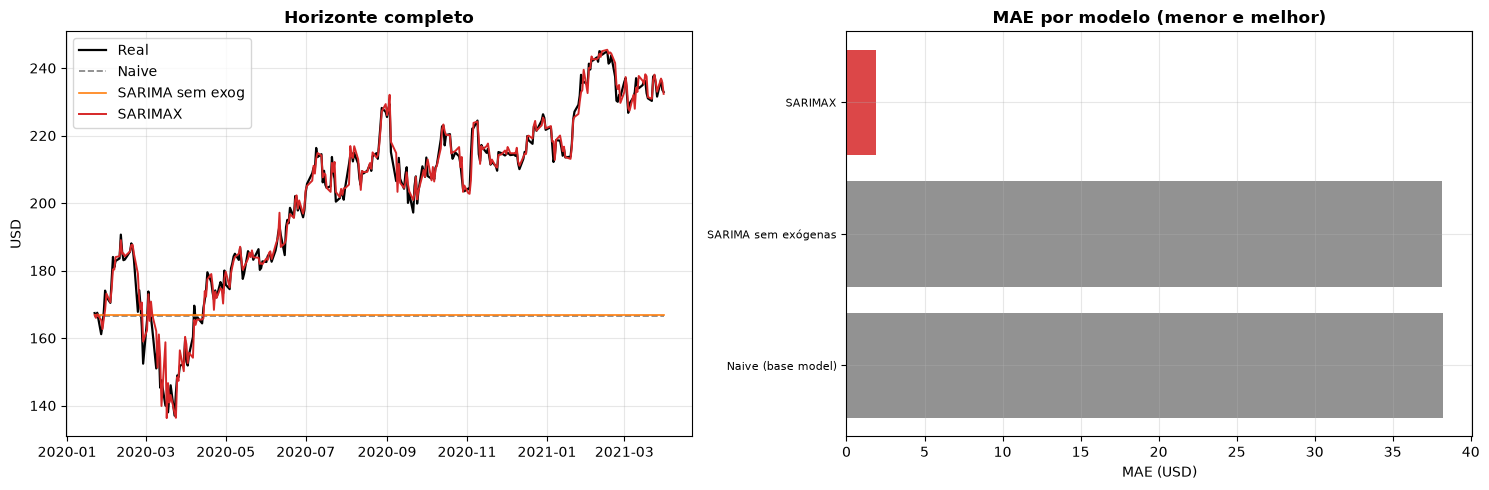

In [22]:
# ---------- Comparacao visual dos tres modelos ----------
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot(datas_te, y_te_raw, color="black", lw=1.6, label="Real")
ax.plot(datas_te, naive_horizonte,  color="#7f7f7f", lw=1.2, ls="--", label="Naive")
ax.plot(datas_te, sarima_horizonte, color="#ff7f0e", lw=1.2, label="SARIMA sem exog")
ax.plot(datas_te, pred_horizonte,   color="#d62728", lw=1.4, label="SARIMAX")
ax.set_title("Horizonte completo", weight="bold"); ax.set_ylabel("USD"); ax.legend(loc="upper left")

ax = axes[1]
ordem_plot = tab.sort_values("MAE", ascending=False)
cores = ["#d62728" if "SARIMAX" in m else "#7f7f7f" for m in ordem_plot.index]
ax.barh(range(len(ordem_plot)), ordem_plot["MAE"], color=cores, alpha=0.85)
ax.set_yticks(range(len(ordem_plot)))
ax.set_yticklabels(ordem_plot.index, fontsize=8)
ax.set_xlabel("MAE (USD)"); ax.set_title("MAE por modelo (menor e melhor)", weight="bold")
plt.tight_layout(); plt.show()

## 7. Validação walk-forward (janela expansiva)

A avaliação das seções anteriores usa uma única origem de previsão: o modelo é estimado
no treino e projeta os 301 pregões de teste de uma só vez. Isso responde à pergunta
"o que o modelo sabia em 23/01/2020 sobre os 14 meses seguintes", que não é a pergunta
que se faz em produção.

Na operação real a rotina é outra: todo dia chega a observação do dia anterior, ela entra
na base e a previsão vale para o próximo pregão. A validação walk-forward reproduz
exatamente essa dinâmica.

Como foi implementado:

1. Janela expansiva. O histórico começa com os 80 por cento de treino e cresce um dia a
   cada passo. Nenhuma observação futura entra no ajuste, então a avaliação continua
   sendo fora da amostra.
2. Horizonte de um passo. Em cada iteração o modelo prevê apenas o próximo pregão.
3. Reestimação a cada 14 passos. Reajustar os coeficientes todo dia custaria 301
   estimações e mudaria pouco o resultado, porque os parâmetros se movem devagar. A cada
   14 pregões, cerca de três semanas de bolsa, os coeficientes são reestimados do zero;
   nos dias intermediários o filtro de Kalman apenas incorpora a nova observação ao
   estado, sem mexer nos parâmetros. É o compromisso usual entre custo computacional e
   aderência.
4. Os benchmarks passam pelo mesmo protocolo, para que a comparação seja feita com todos
   os modelos recebendo a mesma informação.

In [23]:
# ---------- Validacao walk-forward: SARIMAX com exogenas ----------
import time

PASSOS_REFIT = 14
TAM_TESTE    = len(y_te)

def ajusta_sarimax(endog, exog=None):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return SARIMAX(endog, exog=exog, order=ORDER, seasonal_order=SEASONAL, trend="n",
                       enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

print(f"Observacoes de treino inicial : {len(y_tr)} "
      f"({datas_tr.iloc[0].date()} a {datas_tr.iloc[-1].date()})")
print(f"Observacoes de teste walk-forward : {TAM_TESTE} "
      f"({datas_te.iloc[0].date()} a {datas_te.iloc[-1].date()})")
print(f"Reestimacao completa a cada {PASSOS_REFIT} passos")

inicio_wf = time.time()

hist_y, hist_X = y_tr.copy(), X_tr.copy()
res_wf = ajusta_sarimax(hist_y, hist_X)

wf_sarimax, wf_real, wf_datas = [], [], []
n_refits = 1

for i in range(TAM_TESTE):
    passo_y = y_te.iloc[[i]]
    passo_X = X_te.iloc[[i]]

    wf_sarimax.append(float(res_wf.forecast(steps=1, exog=passo_X).iloc[0]))
    wf_real.append(float(y_te_raw.iloc[i]))
    wf_datas.append(datas_te.iloc[i])

    hist_y = pd.concat([hist_y, passo_y])
    hist_X = pd.concat([hist_X, passo_X])

    if (i + 1) % PASSOS_REFIT == 0 or (i + 1) == TAM_TESTE:
        res_wf = ajusta_sarimax(hist_y, hist_X)
        n_refits += 1
    else:
        res_wf = res_wf.append(passo_y, exog=passo_X, refit=False)

elapsed_wf = time.time() - inicio_wf
pred_wf_sarimax = inverter_escala(wf_sarimax)
wf_real = np.asarray(wf_real, dtype=float)

print(f"\nValidacao walk-forward concluida em {elapsed_wf:.2f} segundos "
      f"com {len(wf_datas)} previsoes geradas e {n_refits} reestimacoes.")

Observacoes de treino inicial : 1204 (2015-04-10 a 2020-01-21)
Observacoes de teste walk-forward : 301 (2020-01-22 a 2021-03-31)
Reestimacao completa a cada 14 passos



Validacao walk-forward concluida em 10.69 segundos com 301 previsoes geradas e 23 reestimacoes.


In [24]:
# ---------- Mesmos benchmarks sob o protocolo walk-forward ----------
inicio_bm = time.time()

# Benchmark 1: Naive. Em walk-forward ele deixa de ser uma reta: a cada dia
# a previsao passa a ser o ultimo preco observado, que agora e conhecido.
pred_wf_naive = np.concatenate([[float(y_tr_raw.iloc[-1])], y_te_raw.values[:-1]])

# Benchmark 2: SARIMA sem exogenas, mesma janela expansiva e mesmo ritmo de reestimacao.
hist_y2 = y_tr.copy()
res_wf2 = ajusta_sarimax(hist_y2)
wf_sarima = []

for i in range(TAM_TESTE):
    passo_y = y_te.iloc[[i]]
    wf_sarima.append(float(res_wf2.forecast(steps=1).iloc[0]))
    hist_y2 = pd.concat([hist_y2, passo_y])
    if (i + 1) % PASSOS_REFIT == 0 or (i + 1) == TAM_TESTE:
        res_wf2 = ajusta_sarimax(hist_y2)
    else:
        res_wf2 = res_wf2.append(passo_y, refit=False)

pred_wf_sarima = inverter_escala(wf_sarima)

resultados_wf = [
    metricas(wf_real, pred_wf_sarimax, "SARIMAX (walk-forward)"),
    metricas(wf_real, pred_wf_sarima,  "SARIMA sem exogenas (walk-forward)"),
    metricas(wf_real, pred_wf_naive,   "Naive (walk-forward)"),
]
tabela_wf = pd.DataFrame(resultados_wf).sort_values("MAE").reset_index(drop=True)
print(f"benchmarks concluidos em {time.time() - inicio_bm:.2f} segundos")
display(tabela_wf)

benchmarks concluidos em 2.07 segundos


,modelo,MAE,RMSE,MAPE_%
0,SARIMAX (walk-forward),1.9152,2.8756,1.0212
1,SARIMA sem exogenas (walk-forward),3.1710,4.1821,1.6388
2,Naive (walk-forward),3.2024,4.1791,1.6576


,Horizonte fixo (301 passos),Walk-forward (1 passo)
SARIMAX,1.8980,1.9152
SARIMA sem exogenas,38.1658,3.1710
Naive,38.1979,3.2024


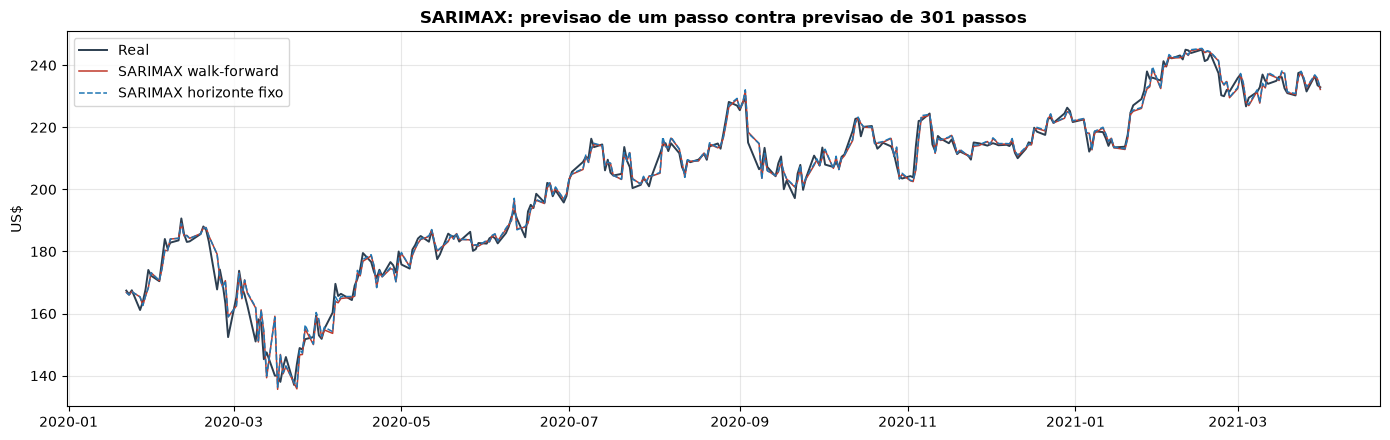

In [25]:
# ---------- Horizonte fixo contra walk-forward ----------
comp = pd.DataFrame(
    {
        "Horizonte fixo (301 passos)": [
            metricas(y_te_raw, pred_horizonte)["MAE"],
            metricas(y_te_raw, sarima_horizonte)["MAE"],
            metricas(y_te_raw, naive_horizonte)["MAE"],
        ],
        "Walk-forward (1 passo)": [
            tabela_wf.set_index("modelo").loc["SARIMAX (walk-forward)", "MAE"],
            tabela_wf.set_index("modelo").loc["SARIMA sem exogenas (walk-forward)", "MAE"],
            tabela_wf.set_index("modelo").loc["Naive (walk-forward)", "MAE"],
        ],
    },
    index=["SARIMAX", "SARIMA sem exogenas", "Naive"],
)
display(comp)

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(wf_datas, wf_real, color="#2c3e50", lw=1.4, label="Real")
ax.plot(wf_datas, pred_wf_sarimax, color="#c0392b", lw=1.1, label="SARIMAX walk-forward")
ax.plot(datas_te, pred_horizonte, color="#1f77b4", lw=1.1, ls="--", label="SARIMAX horizonte fixo")
ax.set_title("SARIMAX: previsao de um passo contra previsao de 301 passos", weight="bold")
ax.set_ylabel("US$")
ax.legend()
plt.tight_layout(); plt.show()

### Leitura

A troca de protocolo muda a conclusão sobre os benchmarks, não sobre o SARIMAX.

No horizonte fixo o Naive e o SARIMA sem exógenas viram uma reta horizontal presa no
último preço do treino, perto de US$ 167, enquanto a ação termina o teste perto de
US$ 233. O erro médio de aproximadamente US$ 38 não mede qualidade de modelagem: mede o
tamanho da alta da Microsoft no período. Pedir 14 meses de previsão a um passeio
aleatório sem informação nova é uma pergunta sem resposta possível.

Sob walk-forward os três modelos recebem a mesma informação a cada dia e os números ficam
comparáveis. O Naive cai de US$ 38,20 para US$ 3,20 e o SARIMA sem exógenas para US$ 3,17,
enquanto o SARIMAX praticamente não se mexe, de US$ 1,90 para US$ 1,92. O Naive passa a
ser um competidor sério, porque em série de preço diário o fechamento de ontem já explica
quase tudo do que abre hoje.

A vantagem do SARIMAX encolhe de vinte vezes para cerca de 40 por cento, e isso é honesto:
parte do ganho que aparecia no horizonte fixo vinha de a exógena `close_lag1`, com
coeficiente próximo de 1, reinjetar o nível do preço a cada passo, informação que no
horizonte fixo os concorrentes não tinham.

O que se leva daqui é a leitura correta do resultado: o SARIMAX entrega ganho real sobre o
passeio aleatório, mas esse ganho é condicionado a dispor das exógenas do dia anterior, o
que só é verdade em previsão de curtíssimo prazo.

## 8. Resultado final na escala original

Todo o modelo trabalhou com dados padronizados, de média 0 e desvio 1. Dizer que o erro foi de
0,04 não comunica nada a quem vai usar o resultado.

Usamos então o `scaler_y` guardado na seção 4 para desfazer a padronização e entregar previsão,
intervalo de confiança e erro em dólares.

In [26]:
tabela = pd.DataFrame(resultados).drop_duplicates(subset="modelo", keep="last")
tabela = tabela.sort_values("MAE").reset_index(drop=True)
display(tabela)

melhor = tabela.iloc[0]
print(f"\n>> Melhor configuração: {melhor['modelo']}")
print(f"   MAE = US$ {melhor['MAE']:.4f} | RMSE = US$ {melhor['RMSE']:.4f} | MAPE = {melhor['MAPE_%']:.3f}%")

,modelo,MAE,RMSE,MAPE_%
0,SARIMAX,1.8980,2.8370,1.0101
1,SARIMA sem exógenas,38.1658,43.5952,17.9326
2,Naive (base model),38.1979,43.6284,17.9475



>> Melhor configuração: SARIMAX
   MAE = US$ 1.8980 | RMSE = US$ 2.8370 | MAPE = 1.010%


In [27]:
# ---------- Diagnóstico do erro de previsão ----------
erro = y_te_raw.values - pred_horizonte
print(f"Erro médio (viés)     : US$ {erro.mean():+.4f}")
print(f"Desvio padrão do erro : US$ {erro.std():.4f}")
print(f"Maior erro absoluto   : US$ {np.abs(erro).max():.4f} em {datas_te.iloc[int(np.abs(erro).argmax())].date()}")


Erro médio (viés)     : US$ -0.3003
Desvio padrão do erro : US$ 2.8211
Maior erro absoluto   : US$ 18.7486 em 2020-03-16


In [28]:
# ---------- Tabela final de previsões na ESCALA ORIGINAL ----------
previsoes = pd.DataFrame({
    "Data": datas_te.values,
    "Open_real_USD": y_te_raw.values,
    "Open_previsto_USD": pred_horizonte,
    "IC95_inf": ic_lo,
    "IC95_sup": ic_hi,
})
previsoes["erro_USD"] = previsoes["Open_real_USD"] - previsoes["Open_previsto_USD"]
display(previsoes.head(8))


,Data,Open_real_USD,Open_previsto_USD,IC95_inf,IC95_sup,erro_USD
0,2020-01-22,167.4000,166.8155,165.3761,168.2550,0.5845
1,2020-01-23,166.1900,165.9937,164.5542,167.4332,0.1963
2,2020-01-24,167.5100,167.0552,165.6157,168.4946,0.4548
3,2020-01-27,161.1500,165.3543,163.9148,166.7937,-4.2043
4,2020-01-28,163.7800,162.6404,161.2009,164.0799,1.1396
5,2020-01-29,167.8400,165.6709,164.2314,167.1104,2.1691
6,2020-01-30,174.0500,168.3129,166.8734,169.7523,5.7371
7,2020-01-31,172.2100,173.1686,171.7292,174.6081,-0.9586


### Cenário what-if

Este bloco não mede erro. Ele responde a uma pergunta hipotética, alimentando
`get_forecast(exog=...)` com valores que não aconteceram.

O cenário escolhido é um choque de mais ou menos dois desvios-padrão em `logvol_lag1`, mantendo
todo o resto constante. A variável foi escolhida por ser significativa a 5%.

In [29]:
# ---------- Cenarios what-if: choque de volume ----------
def cenario(desloc):
    Xc = X_te.copy()
    Xc["logvol_lag1"] = Xc["logvol_lag1"] + desloc
    return inverter_escala(sarimax.get_forecast(steps=h, exog=Xc).predicted_mean)

cen = {
    "Volume +2 desvios": cenario(+2.0),
    "Cenario base (observado)": pred_horizonte,
    "Volume -2 desvios": cenario(-2.0),
}

resumo_cen = pd.DataFrame([
    {"cenario": k,
     "media_prevista_USD": v.mean(),
     "diferenca_vs_base_USD": v.mean() - pred_horizonte.mean()}
    for k, v in cen.items()
])
display(resumo_cen)

,cenario,media_prevista_USD,diferenca_vs_base_USD
0,Volume +2 desvios,202.5604,0.0983
1,Cenario base (observado),202.4621,0.0000
2,Volume -2 desvios,202.3638,-0.0983


O deslocamento segue o sinal do coeficiente de `logvol_lag1` e é pequeno: um choque de dois
desvios-padrão no volume move a previsão média em centavos. O volume de ontem informa, mas não
domina. Quem domina o nível é `close_lag1`, com coeficiente próximo de 1.

Vale repetir que o what-if não mede acurácia, já que não existe valor real para um cenário
hipotético.

## 9. Análise de resíduos

Resíduo é a diferença entre o que aconteceu e o que o modelo previu dentro do período de treino.
Se o modelo capturou tudo o que havia para capturar, o que sobra deve ser puro acaso, sem padrão
nenhum. É o que a literatura chama de ruído branco.

Isso importa porque, se os resíduos ainda tiverem padrão, existe informação na série que o modelo
deixou passar e ele pode ser melhorado. Analisar resíduo é a forma de verificar se o trabalho
está terminado.

Fazemos três perguntas, nesta ordem.

| Pergunta | Teste | Resultado desejado |
|---|---|---|
| Sobrou padrão nos resíduos? | Ljung-Box (H0: é ruído branco) | `p > 0,05`, ou seja, não rejeitar H0 |
| Os resíduos seguem distribuição normal? | Jarque-Bera (H0: são normais) | `p > 0,05` seria o ideal |
| A variância é constante no tempo? | break-var (H0: é constante) | `p > 0,05` seria o ideal |

Atenção a uma inversão que costuma confundir: na primeira pergunta, não rejeitar H0 é o
resultado que queremos. É um dos poucos testes em que p-valor alto é boa notícia.

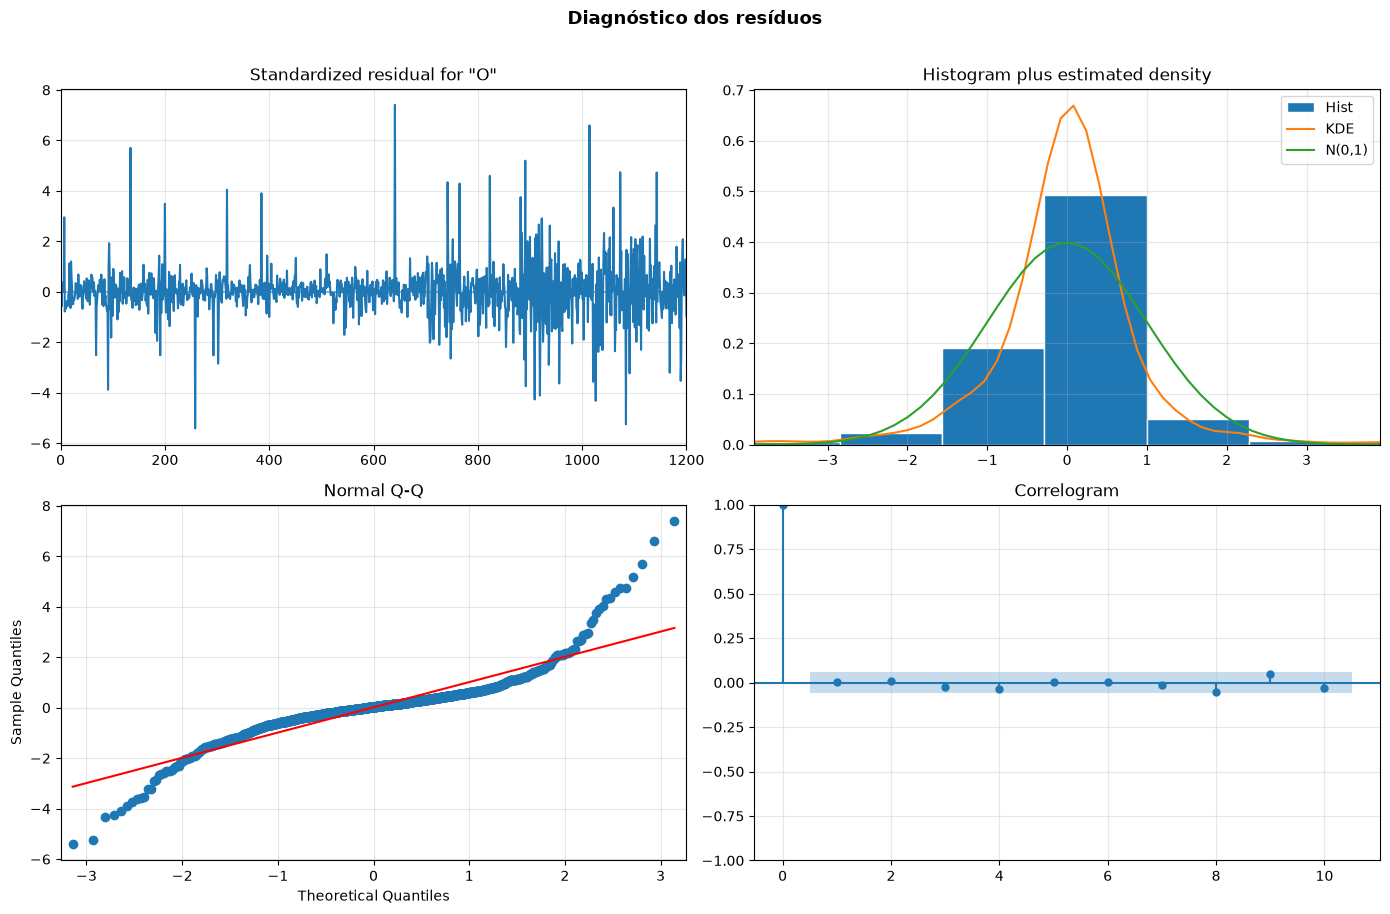

In [30]:
fig = sarimax.plot_diagnostics(figsize=(14, 9))
fig.suptitle("Diagnóstico dos resíduos", y=1.01, fontsize=13, weight="bold")
plt.tight_layout(); plt.show()

In [31]:
resid = sarimax.resid[1:]   # descarta o 1º resíduo (difusão do filtro de Kalman)

# --- Ljung-Box: há autocorrelação remanescente? (H0 = resíduos são ruído branco) ---
lb = acorr_ljungbox(resid, lags=[5, 10, 15, 20, 30], return_df=True)
lb["conclusao"] = np.where(lb["lb_pvalue"] < 0.05,
                           "REJEITA H0 -> ainda há autocorrelação",
                           "não rejeita H0 -> ruído branco")
print("Ljung-Box:"); display(lb)

# --- Normalidade e heterocedasticidade ---
from scipy import stats
jb_stat, jb_p = stats.jarque_bera(resid)
print(f"\nJarque-Bera : estat={jb_stat:.2f} | p-valor={jb_p:.6f} -> "
      f"{'resíduos NÃO normais' if jb_p < 0.05 else 'resíduos normais'}")
print(f"Assimetria  : {stats.skew(resid):.4f}")
print(f"Curtose     : {stats.kurtosis(resid, fisher=False):.4f}  (normal = 3)")
print(f"Média       : {resid.mean():.6f}  (ideal: próximo de 0)")

het = sarimax.test_heteroskedasticity(method="breakvar")[0]
print(f"Heterocedasticidade (break-var): estat={het[0]:.4f} | p-valor={het[1]:.6f} -> "
      f"{'variância NÃO constante' if het[1] < 0.05 else 'variância constante'}")

Ljung-Box:


,lb_stat,lb_pvalue,conclusao
5,2.4732,0.7805,não rejeita H0 -> ruído branco
10,9.4520,0.4898,não rejeita H0 -> ruído branco
15,13.8952,0.5335,não rejeita H0 -> ruído branco
20,18.1837,0.5753,não rejeita H0 -> ruído branco
30,25.8031,0.6851,não rejeita H0 -> ruído branco



Jarque-Bera : estat=4976.52 | p-valor=0.000000 -> resíduos NÃO normais
Assimetria  : 0.6490
Curtose     : 12.8791  (normal = 3)
Média       : 0.000342  (ideal: próximo de 0)
Heterocedasticidade (break-var): estat=2.9841 | p-valor=0.000000 -> variância NÃO constante


### Discussão dos resíduos

O Ljung-Box não rejeita H0 em nenhum lag, com todos os p-valores acima de 0,48. Os resíduos são
ruído branco, o que indica que a parte ARIMA capturou toda a autocorrelação disponível. É o
resultado desejado.

O Jarque-Bera tem p-valor praticamente zero e a curtose está muito acima de 3. São caudas
pesadas, comportamento típico de ativo financeiro e reflexo do crash de março de 2020. Isso não
invalida a previsão pontual, mas deixa os intervalos de confiança otimistas.

A heterocedasticidade é significativa, sinal de que a volatilidade muda de regime ao longo do
período. Já a média dos resíduos fica praticamente em zero, o que descarta viés sistemático.

## 10. Conclusões

### Exógenas

As quatro selecionadas são significativas a 5% e têm VIF próximo de 1, portanto não há
redundância entre elas.

| Variável | Tipo | Informação | VIF |
|---|---|---|---|
| `close_lag1` | Prevista | nível do preço | 1,01 |
| `ret_lag1` | Prevista | direção | 1,00 |
| `logvol_lag1` | Prevista | intensidade | 1,01 |
| `dow_sexta` | Determinística | calendário | 1,00 |

`High`, `Low`, `Close` e `Volume` do mesmo dia ficaram de fora porque só existem depois do
pregão. Por isso usamos as versões defasadas, já conhecidas na abertura.

### Ordem

O grid search percorreu 32 combinações, com `p` e `q` em {0, 1}, `d = 1` definido por ADF e
KPSS, e `P`, `D`, `Q` em {0, 1} sobre `m = 5`. Todas convergiram. A vencedora por BIC foi
SARIMAX(0,1,1)(0,0,0,5), com BIC de -5.646,48, ou seja, sem componente sazonal ativo: a
semana de pregão foi testada e descartada pelo próprio critério.

### Benchmarks e desempenho

| Modelo | MAE (USD) |
|---|---|
| SARIMAX | 1,90 |
| SARIMA sem exógenas | 38,17 |
| Naive | 38,20 |

Os dois benchmarks empatam, e a razão é estrutural. Sem drift, a previsão de um passeio
aleatório para `k` passos é sempre o último valor do treino, cerca de US$ 167, o que produz uma
reta. Como a MSFT subiu até cerca de US$ 233, o MAE de 38 é literalmente o tamanho da alta no
período. Todo o ganho do modelo vem das exógenas, com diferença de BIC de -1.145,39.

O SARIMAX fechou com MAE de US$ 1,8980, RMSE de US$ 2,8370 e MAPE de 1,010% em 302 pregões, um
intervalo que inclui o crash da COVID. O viés é praticamente nulo, em US$ -0,30, e o pior erro
foi de US$ 18,75 em 16/03/2020, o auge do crash.

### Ressalva

`close_lag1` tem coeficiente 1,0001, e `Close(t-1)` é próximo de `Open(t)` por construção do
mercado. O modelo usa corretamente a informação mais recente disponível, mas não prevê o mercado:
a avaliação usa `X_te` real, o que configura um teto otimista.

### Limitação e extensão

Os resíduos são ruído branco, mas não são normais e apresentam heterocedasticidade. A extensão
natural do trabalho seria modelar a variância com um GARCH sobre esses resíduos.